In [1]:
import h5py
import numpy as np
import os
import matplotlib.pyplot as plt
from scipy.ndimage import label
from skimage import morphology
from skimage import measure
from scipy import ndimage as ndi
from skimage.segmentation import find_boundaries
from scipy.stats import gaussian_kde
from matplotlib.patches import FancyArrowPatch
from scipy.optimize import curve_fit
from scipy.ndimage import map_coordinates
import seaborn as sns
from scipy.ndimage import maximum_filter, label

In [2]:
#Defining all the required functions

#Fourier Transform Functions
def partial_x_fft(f, dx):
    nx, ny = f.shape
    kx = 2 * np.pi * np.fft.fftfreq(nx, d=dx)
    f_fft = np.fft.fft(f, axis=0)
    df_fft = 1j * kx[:, None] * f_fft
    return np.real(np.fft.ifft(df_fft, axis=0))

def partial_y_fft(f, dy):
    nx, ny = f.shape
    ky = 2 * np.pi * np.fft.fftfreq(ny, d=dy)
    f_fft = np.fft.fft(f, axis=1)
    df_fft = 1j * ky[None, :] * f_fft
    return np.real(np.fft.ifft(df_fft, axis=1))

#Defining constants
dx = 0.0625
dy = 0.0625

In [3]:
#Denoising the data
def gaussian_fft_filter_2d(J_squared, k0):
    """
    Apply a Gaussian low-pass filter in Fourier space to a 2D field.

    Parameters
    ----------
    J_squared : 2D numpy array
        Input real-space data
    k0 : float
        Filter width in k-space (grid units). Smaller = stronger smoothing.

    Returns
    -------
    J_filtered : 2D numpy array
        Smoothed real-space data
    """

    # FFT
    F = np.fft.fft2(J_squared)
    F_shifted = np.fft.fftshift(F)

    # k-grid
    nx, ny = J_squared.shape
    kx = np.fft.fftshift(np.fft.fftfreq(nx)) * nx
    ky = np.fft.fftshift(np.fft.fftfreq(ny)) * ny
    KX, KY = np.meshgrid(kx, ky, indexing='ij')
    K2 = KX**2 + KY**2

    # Gaussian filter in k-space
    gaussian = np.exp(-K2 / (2 * k0**2))

    # Apply filter
    F_filt = F_shifted * gaussian

    # Inverse FFT
    F_filt = np.fft.ifftshift(F_filt)
    J_filtered = np.fft.ifft2(F_filt)

    # Return real part
    return np.real(J_filtered)

In [32]:
#Lets Computer J_total

# 1. Read the HDF5 file
File_Bx = '/DATA/DEVESH/ExtremeBetaSimulations/0.0625/Bx_ApJ_t250.h5'  # Replace with your file path
File_By = '/DATA/DEVESH/ExtremeBetaSimulations/0.0625/By_ApJ_t250.h5'  # Replace with your file path
File_Bz = '/DATA/DEVESH/ExtremeBetaSimulations/0.0625/Bz_ApJ_t250.h5'  # Replace with your file path

# with h5py.File(File_Bx, 'r') as fBx, h5py.File(File_By, 'r') as fBy, h5py.File(File_Bz, 'r') as fBz:
#     data_Bx = fBx['DS1'][:].T
#     data_By = fBy['DS1'][:].T
#     data_Bz = fBz['DS1'][:].T
#     data_Jx = partial_y_fft(data_Bz,dx)
#     data_Jy = -partial_x_fft(data_Bz,dy)
#     data_Jz = partial_x_fft(data_By,dy)-partial_y_fft(data_Bx,dx)

# J_squared = np.abs(np.sqrt(data_Jx**2 + data_Jy**2 + data_Jz**2))
# J_squared = gaussian_fft_filter_2d(J_squared, k0=0.05 * len(data_Bx))

with h5py.File(File_Bx, 'r') as fBx, h5py.File(File_By, 'r') as fBy, h5py.File(File_Bz, 'r') as fBz:
    data_Bx = fBx['DS1'][:].T
    data_By = fBy['DS1'][:].T
    data_Bz = fBz['DS1'][:].T
    data_Bx_filtered = gaussian_fft_filter_2d(data_Bx, k0=0.05 * len(data_Bx))
    data_By_filtered = gaussian_fft_filter_2d(data_By, k0=0.05 * len(data_Bx))
    data_Bz_filtered = gaussian_fft_filter_2d(data_Bz, k0=0.05 * len(data_Bx))
    data_Jx = partial_y_fft(data_Bz_filtered,dx)
    data_Jy = -partial_x_fft(data_Bz_filtered,dy)
    data_Jz = partial_x_fft(data_By_filtered,dy)-partial_y_fft(data_Bx_filtered,dx)

J_squared = np.abs(np.sqrt(data_Jx**2 + data_Jy**2 + data_Jz**2))
J_squared = gaussian_fft_filter_2d(J_squared, k0=0.05 * len(data_Bx))


#Different Strategies for Threshold
#Strategy 1: Pick top 10% of the features
threshold = np.quantile(J_squared, 0.8)

#Strategy 2: 
# N = 3
# J_squared_rms = np.sqrt(np.mean(J_squared**2))
# threshold = np.mean(J_squared) + N*J_squared_rms

print("Threshold:", threshold)

binary_mask = np.abs(J_squared) > threshold


# MORPHOLOGICAL SMOOTHING
struct = morphology.disk(5)

smoothed_mask = morphology.binary_opening(binary_mask, struct)
smoothed_mask = morphology.binary_closing(smoothed_mask, struct)
smoothed_mask = smoothed_mask.astype(int)

# Remove small areas
min_area = 300 # choose based on eye balling
cleaned_mask = morphology.remove_small_objects(smoothed_mask.astype(bool), min_size=min_area).astype(int)

Threshold: 0.22057067516680223


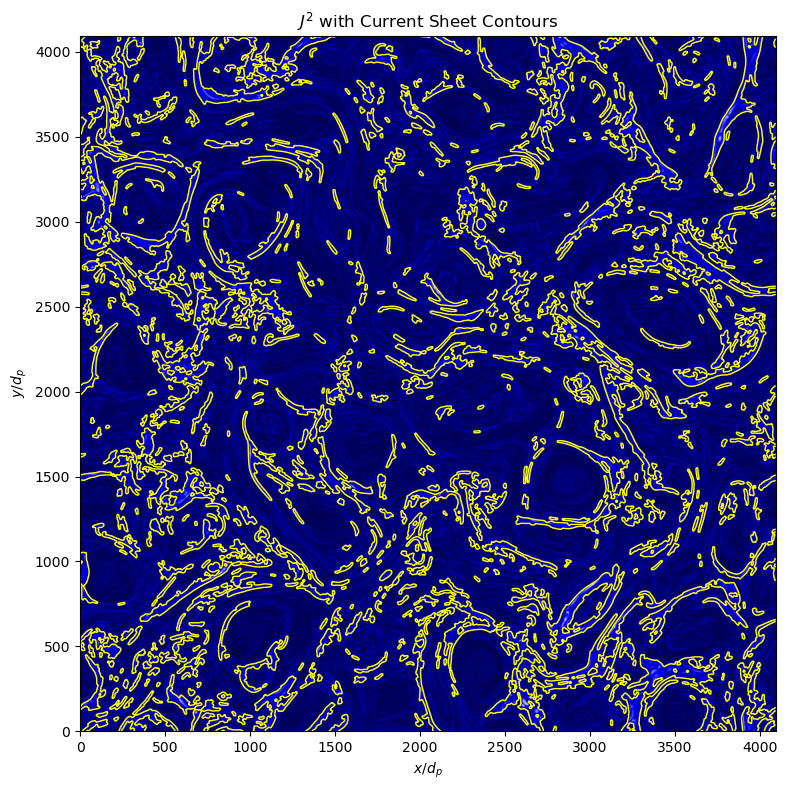

In [34]:
#Plot current sheets over the base J_squared field

plt.figure(figsize=(10, 8))

# Base field
plt.imshow(J_squared.T, cmap='seismic', origin='lower', vmax=2)
# plt.imshow(J_squared.T, cmap='seismic', origin='lower')

# Add current-sheet boundaries
plt.contour(cleaned_mask.T, levels=[0.5], colors='yellow', linewidths=1)

plt.title(r'$J^{2}$ with Current Sheet Contours')
plt.xlabel(r'$x/d_p$')
plt.ylabel(r'$y/d_p$')
plt.tight_layout()
plt.savefig("J2_NR_with_CS_contours.png", dpi=300)
plt.show()

In [22]:
np.max(J_squared)

np.float64(11.289176957131502)

In [6]:
#FIND MAXIMUM IN EACH CONNECTED REGION

labeled_mask, num_features = label(cleaned_mask)
print("Regions found:", num_features)

max_coords = []
max_values = []

for i in range(1, num_features + 1):
    region_mask = (labeled_mask == i)
    region_vals = J_squared[region_mask]

    if region_vals.size == 0:
        continue

    # Extreme value (max magnitude)
    max_pos = np.argmax(np.abs(region_vals))
    extreme_value = region_vals[max_pos]
    max_values.append(extreme_value)

    # Convert index → coordinates
    xs, ys = np.where(region_mask)
    max_coords.append((xs[max_pos], ys[max_pos]))

Regions found: 335


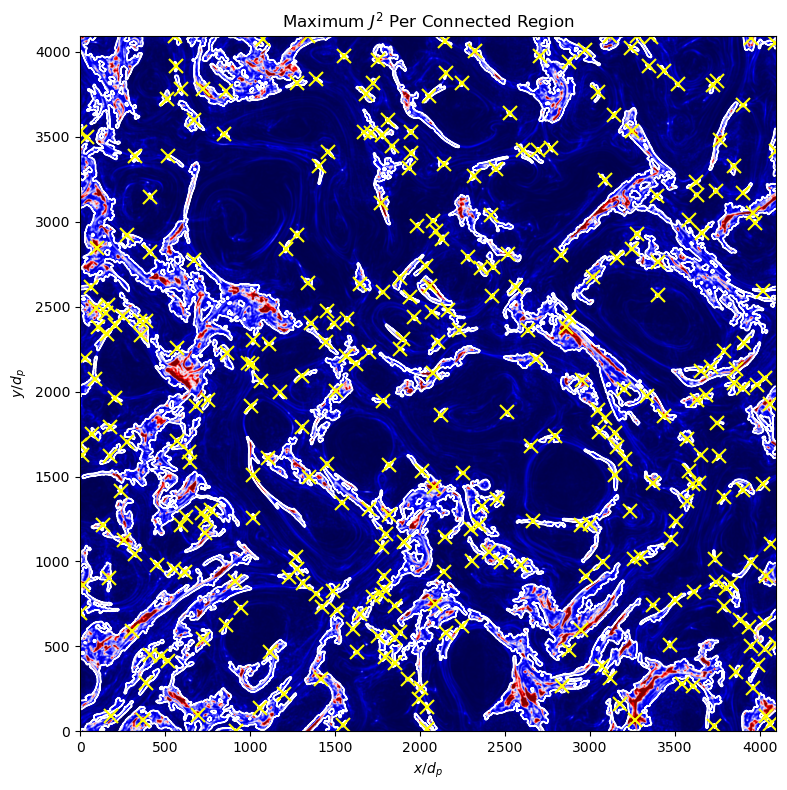

In [7]:
# PLOT ORIGINAL FIELD + MASK + MAXIMUM POINTS

plt.figure(figsize=(10, 8))

# --- Base field ---
plt.imshow(J_squared.T, cmap='seismic', origin='lower', vmax=2.25)

# --- Boundaries of CSs---
boundaries = find_boundaries(labeled_mask)
plt.contour(boundaries.T, levels=[0.5], colors='white', linewidths=1)

# --- Overlay maxima as yellow crosses ---
for x, y in max_coords:
    plt.plot(x, y, marker='x', markersize=10, markeredgewidth=1.5, color='yellow')

plt.title(r'Maximum $J^{2}$ Per Connected Region')
plt.xlabel(r'$x/d_p$')
plt.ylabel(r'$y/d_p$')

plt.tight_layout()
plt.savefig("J2_NR_maxima_overlay_Beta_0.0625.png", dpi=300)
plt.show()

Number of connected regions: 333
Found 333 sheets
Mean thickness = 32.316 pixels
Median thickness = 22.361 pixels
Min thickness = 10.770 px, Max = 179.120 px


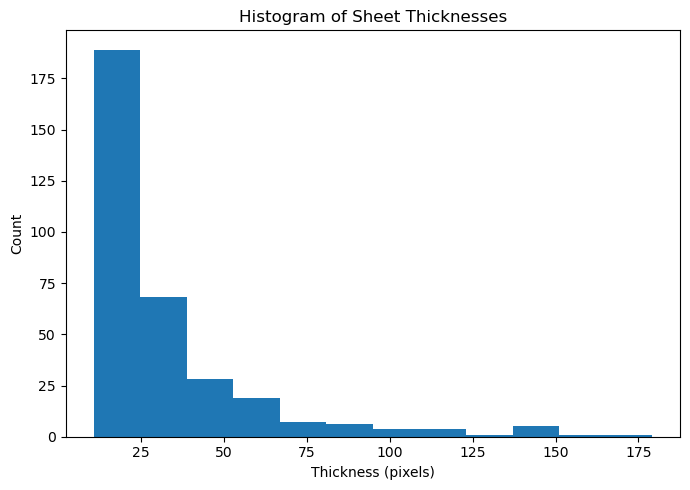

In [24]:
# Method 1 for Thickness Computation: Using the internal function for diameter of largest inscribed circle

#1. Labelling each connected region

labeled_mask = measure.label(cleaned_mask, connectivity=2)
num_regions = labeled_mask.max()
print("Number of connected regions:", num_regions)

#2. Compute thicknesses

thicknesses_m1 = []

for label_id in range(1, num_regions + 1):

    region = (labeled_mask == label_id)

    # Euclidean distance transform INSIDE the region
    dist = ndi.distance_transform_edt(region)

    # Full sheet thickness = diameter of largest inscribed circle
    thickness = 2 * dist.max()

    thicknesses_m1.append(thickness)

# 3. Some Central Measures of the statistics

print(f"Found {len(thicknesses_m1)} sheets")
print(f"Mean thickness = {np.mean(thicknesses_m1):.3f} pixels")
print(f"Median thickness = {np.median(thicknesses_m1):.3f} pixels")
print(f"Min thickness = {np.min(thicknesses_m1):.3f} px, Max = {np.max(thicknesses_m1):.3f} px")

# 4. Histogram of thicknesses

plt.figure(figsize=(7,5))
plt.hist(thicknesses_m1, bins=12)
plt.xlabel("Thickness (pixels)")
plt.ylabel("Count")
plt.title("Histogram of Sheet Thicknesses")
plt.tight_layout()
plt.savefig("J2_NR_M1_Beta_0.0625_Histogram.png", dpi=300)
plt.show()    

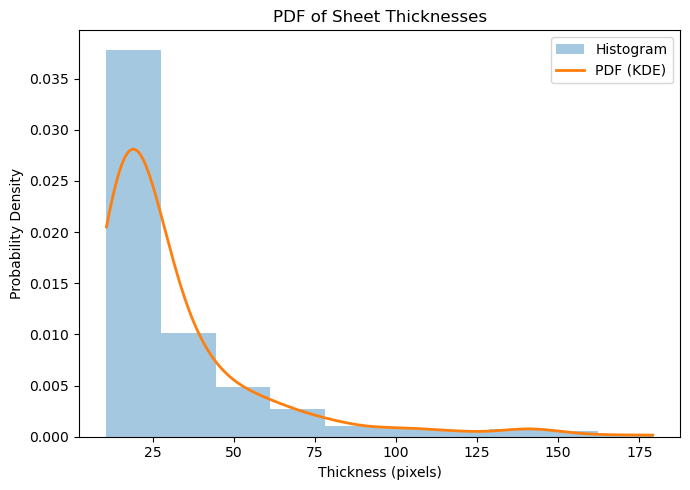

In [26]:
#Plot a smooth PDF of the same data
plt.figure(figsize=(7,5))

# Histogram (normalized)
plt.hist(thicknesses_m1, bins=10, density=True, alpha=0.4, label="Histogram")

# KDE curve
kde = gaussian_kde(thicknesses_m1)
xs = np.linspace(min(thicknesses_m1), max(thicknesses_m1), 500)
plt.plot(xs, kde(xs), linewidth=2, label="PDF (KDE)")
plt.xlabel("Thickness (pixels)")
plt.ylabel("Probability Density")
plt.title("PDF of Sheet Thicknesses")
plt.legend()
plt.tight_layout()
plt.savefig("J2_NR_M1_PDF.png", dpi=300)
plt.show()

In [42]:
# 1. Read the HDF5 file
File_Bx = '/DATA/DEVESH/ExtremeBetaSimulations/0.0625/Bx_ApJ_t250.h5'  # Replace with your file path
File_By = '/DATA/DEVESH/ExtremeBetaSimulations/0.0625/By_ApJ_t250.h5'  # Replace with your file path
File_Bz = '/DATA/DEVESH/ExtremeBetaSimulations/0.0625/Bz_ApJ_t250.h5'  # Replace with your file path

with h5py.File(File_Bx, 'r') as fBx, h5py.File(File_By, 'r') as fBy, h5py.File(File_Bz, 'r') as fBz:
    data_Bx = fBx['DS1'][:].T
    data_By = fBy['DS1'][:].T
    data_Bz = fBz['DS1'][:].T
    data_Bx_filtered = gaussian_fft_filter_2d(data_Bx, k0=0.05 * len(data_Bx))
    data_By_filtered = gaussian_fft_filter_2d(data_By, k0=0.05 * len(data_Bx))
    data_Bz_filtered = gaussian_fft_filter_2d(data_Bz, k0=0.05 * len(data_Bx))
    data_Jx = partial_y_fft(data_Bz_filtered,dx)
    data_Jy = -partial_x_fft(data_Bz_filtered,dy)
    data_Jz = partial_x_fft(data_By_filtered,dy)-partial_y_fft(data_Bx_filtered,dx)

J_squared = data_Jx**2 + data_Jy**2 + data_Jz**2
J_squared = gaussian_fft_filter_2d(J_squared, k0=0.05 * len(data_Bx))

In [35]:
# Method 4: Finding maxima first and then find thickness(Zhdankin Algorithm)

def local_maxima_mask(field, threshold, n):
    
    # Apply threshold
    mask = field > threshold
    
    # Compute local maximum in a (2n+1)x(2n+1) neighborhood
    local_max = maximum_filter(field, size=(2*n+1), mode='wrap')
    
    # Keep only points that are equal to local maximum and above threshold
    maxima_mask = (field == local_max) & mask
    
    return maxima_mask.astype(int)

def grow_regions(J2_FT, maxima_mask, J_thresh_region):
    """Grow regions above region threshold connected to local maxima."""
    J_abs = np.abs(J2_FT)

    # Mask of all points above region threshold
    above_thresh = (J_abs > J_thresh_region).astype(int)

    # Label connected regions
    labeled_regions, num_features = label(above_thresh, structure=np.ones((3,3)))

    # Keep only those regions that contain a local maximum
    keep_labels = np.unique(labeled_regions[maxima_mask.astype(bool)])
    keep_labels = keep_labels[keep_labels > 0]  # drop background=0

    region_mask = np.isin(labeled_regions, keep_labels).astype(int)

    return region_mask, labeled_regions

J_squared_rms = np.sqrt(np.mean(J_squared**2))
n = 200   # neighborhood radius
maxima_mask = local_maxima_mask(J_squared, 3*J_squared_rms, n)

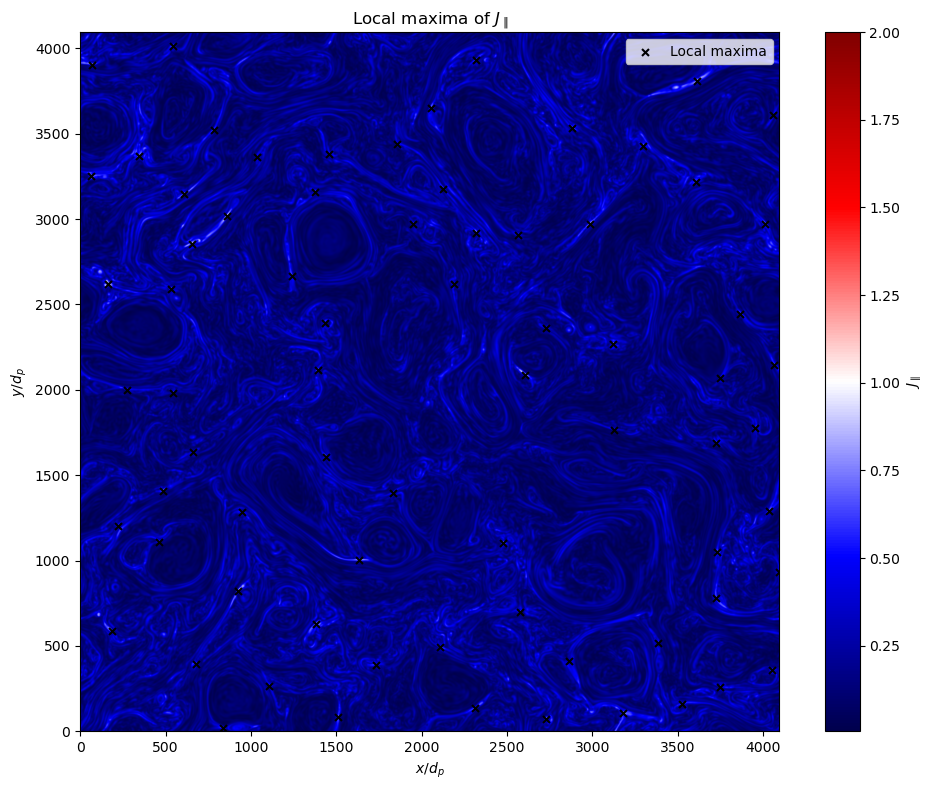

In [37]:
# Plot J_squared with maxima overlay
plt.figure(figsize=(10, 8))
# img = plt.imshow(J_squared, cmap='seismic', vmin=-1.5, vmax=1.5, origin='lower')
img = plt.imshow(J_squared, cmap='seismic',vmax=2, origin='lower')
plt.colorbar(img, label=r'$J_\parallel$')

# Overlay local maxima
y_idx, x_idx = np.where(maxima_mask)
plt.scatter(x_idx, y_idx, marker='x', color='black', s=25, label='Local maxima')

plt.title(r'Local maxima of $J_\parallel$')
plt.xlabel(r'$x/d_{p}$')
plt.ylabel(r'$y/d_{p}$')
plt.legend()
plt.tight_layout()
plt.show()

In [40]:
#Calculating J_squared_rms
J_squared_rms = np.sqrt(np.mean(J_squared**2))

# Defining Thresholds
J2_thresh_peak = 3*J_squared_rms     # threshold for detecting maxima
J2_thresh_region = 0.05*np.max(J_squared)   # threshold for growing regions
n = 200                   # neighborhood radius for non-max suppression

# Step 1: detect peaks
maxima_mask = local_maxima_mask(J_squared, J2_thresh_peak, n)

# Step 2: grow regions around peaks
region_mask, labeled_regions = grow_regions(J_squared, maxima_mask, J2_thresh_region)

#MORPHOLOGICAL SMOOTHING
struct = morphology.disk(5)

smoothed_mask = morphology.binary_opening(region_mask, struct)
smoothed_mask = morphology.binary_closing(smoothed_mask, struct)
smoothed_mask = smoothed_mask.astype(int)

# Number of Current sheets
labeled_mask, num_features = label(smoothed_mask)
print("Regions found:", num_features)

# # Step 3: plot results
# plt.figure(figsize=(10, 8))
# img = plt.imshow(J_squared.T, cmap='seismic', vmax=0.05, origin='lower')
# plt.colorbar(img, label=r'$J^2$')

# # Overlay region mask as small white dots
# y_reg, x_reg = np.where(region_mask == 1)
# plt.scatter(y_reg, x_reg, s=5, color='black', alpha=0.6, label='Regions above J_thresh_region')

# # Overlay maxima as red X’s
# y_peak, x_peak = np.where(maxima_mask == 1)
# plt.scatter(y_peak, x_peak, marker='x', color='red', s=50, label='Local maxima')

# plt.title(r'Current sheet peaks and regions')
# plt.xlabel(r'$x/d_{p}$')
# plt.ylabel(r'$y/d_{p}$')
# # plt.legend()
# plt.tight_layout()
# plt.savefig("J2_NR_M4_maxima_overlay.png", dpi=300)
# plt.show()

Regions found: 12


In [41]:
# Compute gradient of J_squared
dJdx, dJdy = np.gradient(J_squared)  # assumes unit grid spacing

descent_dirs = []  # (dx, dy) unit vectors

y_peak, x_peak = np.where(maxima_mask == 1)
max_coords = list(zip(y_peak, x_peak))

for (x, y) in max_coords:
    gx = dJdx[x, y]
    gy = dJdy[x, y]

    grad = np.array([gx, gy])

    # Avoid division by zero
    if np.allclose(grad, 0):
        descent_dirs.append(np.array([0.0, 0.0]))
        continue

    # Direction of steepest descent = negative normalized gradient
    descent = -grad / np.linalg.norm(grad)
    descent_dirs.append(descent)

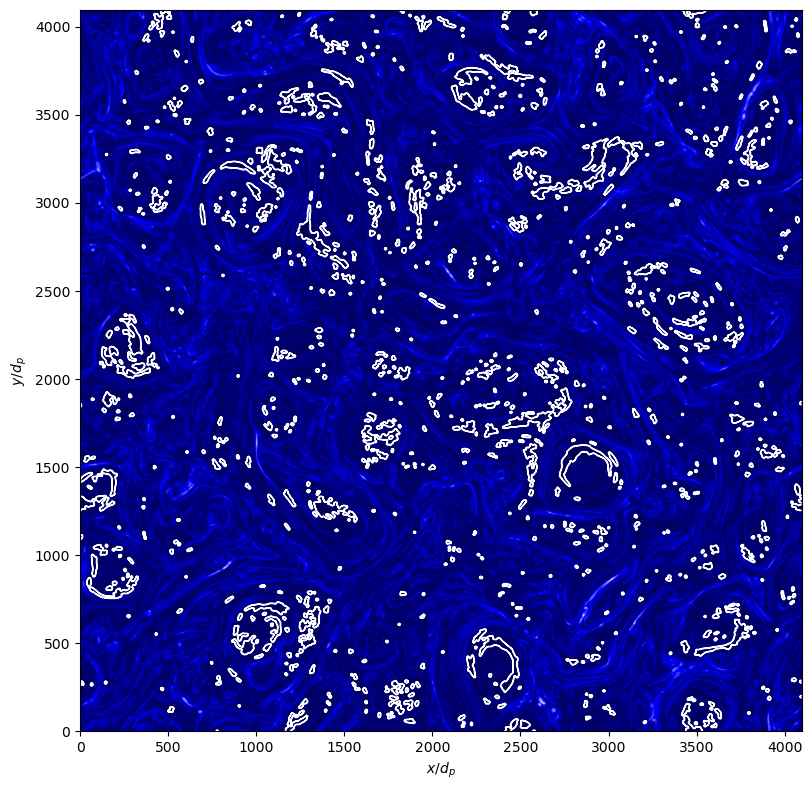

In [43]:
# Plotting the steepest descent direction
fig, ax = plt.subplots(figsize=(10, 8))

# --- Base field image ---
ax.imshow(J_squared.T, cmap='seismic', origin='lower', vmax=2, aspect='equal', zorder=0)

# --- Boundaries of connected structures ---
boundaries = find_boundaries(labeled_mask)
ax.contour(boundaries.T, levels=[0.5], colors='white', linewidths=1, zorder=2)

# # --- Arrows for maxima (always on top) ---
# factor = 100.0
# for (x, y), (dx, dy) in zip(max_coords, descent_dirs):

#     start = (x - 0.5 * factor * dx, y - 0.5 * factor * dy)
#     end   = (x + 0.5 * factor * dx, y + 0.5 * factor * dy)

#     arrow = FancyArrowPatch(
#         start, end,
#         arrowstyle="<->",
#         color="red",
#         mutation_scale=10,
#         linewidth=2,
#         zorder=10             
#     )
#     ax.add_patch(arrow)

# --- Axis labels & title ---
ax.set_title(r'')
ax.set_xlabel(r'$x/d_p$')
ax.set_ylabel(r'$y/d_p$')

# --- Save clean figure ---
plt.tight_layout()
plt.savefig("J2_NR_M4_Descent_Direction.png", dpi=300)

plt.show()

In [34]:
distances = []

for (x, y), (dx, dy) in zip(max_coords, descent_dirs):
    x, y = float(x), float(y)  # ensure float for stepping
    step_size = 1  # pixel step
    max_steps = 1000  # prevent infinite loop
    
    # Step forward
    xf, yf = x, y
    steps = 0
    while steps < max_steps:
        xf_new = xf + dx*step_size
        yf_new = yf + dy*step_size
        xi, yi = int(round(xf_new)), int(round(yf_new))
        if xi < 0 or yi < 0 or xi >= smoothed_mask.shape[0] or yi >= smoothed_mask.shape[1]:
            break
        if not smoothed_mask[xi, yi]:  # left the connected region
            break
        xf, yf = xf_new, yf_new
        steps += 1
    dist_forward = np.hypot(xf - x, yf - y)

    # Step backward
    xb, yb = x, y
    steps = 0
    while steps < max_steps:
        xb_new = xb - dx*step_size
        yb_new = yb - dy*step_size
        xi, yi = int(round(xb_new)), int(round(yb_new))
        if xi < 0 or yi < 0 or xi >= smoothed_mask.shape[0] or yi >= smoothed_mask.shape[1]:
            break
        if not smoothed_mask[xi, yi]:  # left the connected region
            break
        xb, yb = xb_new, yb_new
        steps += 1
    dist_backward = np.hypot(xb - x, yb - y)

    distances.append((dist_backward, dist_forward))

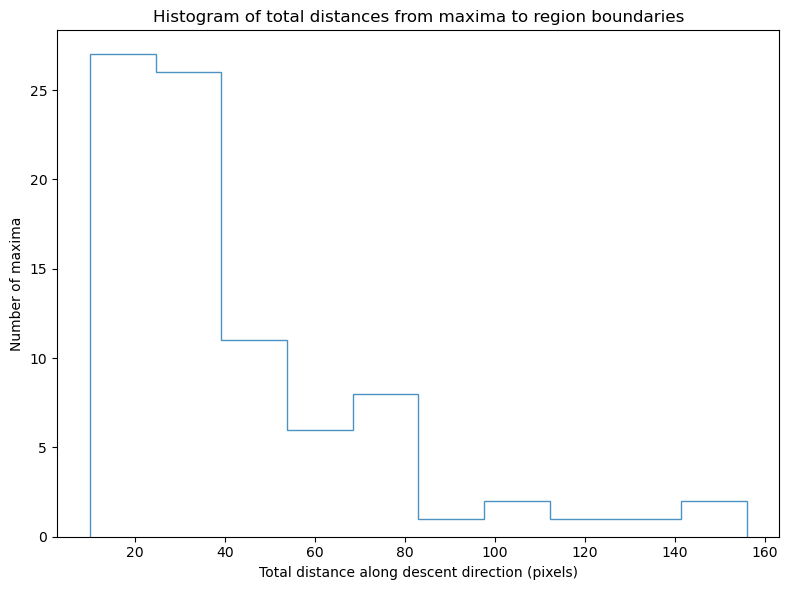

In [35]:
# Calculate total distance for each maximum = thickness
thicknesses_m4 = np.array([d[0] + d[1] for d in distances])
# thicknesses_m4 = np.array(thicknesses_m4)[np.array(thicknesses_m4) <= 100]
# thicknesses_m4 = np.array(thicknesses_m4)[np.array(thicknesses_m4) > 0]

# Plot histogram
plt.figure(figsize=(8, 6))
plt.hist(thicknesses_m4, bins=10, histtype='step', alpha=0.8)
plt.xlabel('Total distance along descent direction (pixels)')
plt.ylabel('Number of maxima')
plt.title('Histogram of total distances from maxima to region boundaries')
plt.tight_layout()
plt.savefig("J2_NR_M4_Histogram.png", dpi=300)
plt.show()